# IMDb Sentiment Analysis with Machine Learning

**Author:** Angelo Miletić  
**Project Type:** NLP / Binary Text Classification  
**Tools Used:** Python, pandas, scikit-learn, imbalanced-learn, Jupyter Notebook

## Project Overview
This notebook presents an end-to-end machine learning workflow for classifying IMDb movie reviews as positive or negative.

## Dataset Description
The dataset contains IMDb movie reviews and their corresponding sentiment labels.  
Each review is labeled as either **positive** or **negative**, making this a binary classification problem.

In [1]:
import pandas as pd

In [2]:
df_reviews = pd.read_csv("IMDB Dataset.csv")

In [3]:
df_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df_positive = df_reviews[df_reviews["sentiment"]=="positive"][:9000]

In [5]:
df_negative = df_reviews[df_reviews["sentiment"]=="negative"][:1000]

In [6]:
df_reviews_imb = pd.concat([df_positive, df_negative])

In [7]:
df_reviews_imb.value_counts("sentiment")

sentiment
positive    9000
negative    1000
Name: count, dtype: int64

## Dealing with Imbalanced Classes

<Axes: xlabel='sentiment'>

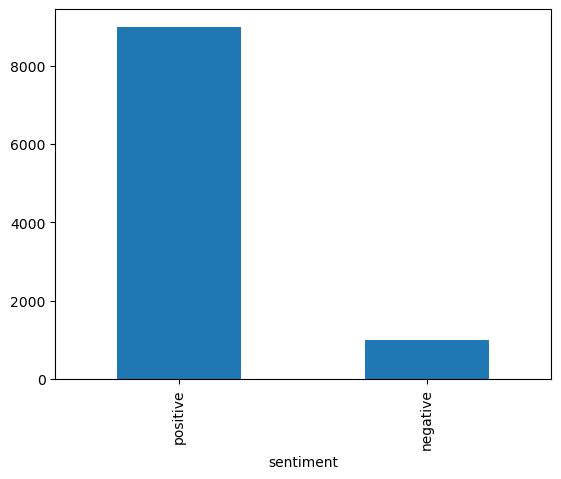

In [8]:
df_reviews_imb.value_counts("sentiment").plot(kind="bar")

## sample()

In [9]:
length_negative = len(df_reviews_imb[df_reviews_imb["sentiment"]=="negative"])

In [10]:
length_negative

1000

In [11]:
df_reviews_positive = df_reviews_imb[df_reviews_imb["sentiment"]=="positive"].sample(n=length_negative)

In [12]:
df_reviews_negative = df_reviews_imb[df_reviews_imb["sentiment"]=="negative"]

In [13]:
pd.concat([df_reviews_positive, df_reviews_negative]).value_counts("sentiment")

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

In [14]:
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])

In [15]:
df_reviews_bal.reset_index(drop=True, inplace=True)

In [16]:
df_reviews_bal

,review,sentiment
0,"Based on fact, this is the story of a teenager...",positive
1,"If I'm going to watch a porn movie, I prefer i...",positive
2,"If you take the movie for what it is worth, yo...",positive
3,This short film that inspired the soon-to-be f...,positive
4,Marvelous film again dealing with the trials a...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


## Balancing data with RandomUnderSampler

In [17]:
from imblearn.under_sampling import RandomUnderSampler

In [18]:
rus = RandomUnderSampler(random_state=0)

df_reviews_bal, df_reviews_bal["sentiment"] = rus.fit_resample(df_reviews_imb[["review"]], df_reviews_imb["sentiment"])

In [19]:
df_reviews_bal.value_counts("sentiment")

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

## Splitting data into train and test

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
train, test = train_test_split(df_reviews_bal, test_size=0.33, random_state=42)

In [22]:
train

,review,sentiment
144,"I just got back from this free screening, and ...",negative
1839,Claire Denis's movies seem to fall into one of...,negative
16588,"One must admit, that Dev has an eye for beauty...",positive
742,Mario Lewis of the Competitive Enterprise Inst...,negative
9464,"The first, and far better, of Kevin Kline's tw...",positive
...,...,...
10644,I saw the movie in Izmir as the closing film o...,positive
16133,This is a great documentary and above comments...,positive
1739,"Obviously, the comments above that fawn over t...",negative
2443,Robert Carlyle excels again. The period was ca...,positive


In [23]:
test

,review,sentiment
11301,Refreshing `lost' gem! Featuring effective dia...,positive
681,Never saw the original movie in the series...I...,negative
7513,"Once upon a time, in Sweden, there was a poor ...",positive
1821,"At the beginning of the film, you might double...",negative
549,Another Spanish movie about the 1936 Civil War...,positive
...,...,...
207,"I have seen most, if not all of the Laurel & H...",negative
7616,D.W. Griffith could have made any film he want...,positive
13483,"Cardiff, Wales. A bunch of 5 mates are deeply ...",positive
1051,I rented this movie with my friend for a good ...,negative


In [24]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [25]:
train_y.value_counts()

sentiment
negative    675
positive    665
Name: count, dtype: int64

## Text Representation (Bag of Words) - model

In [26]:
#Count Vectorizer
from sklearn.feature_extraction.text import CountVectorizer

text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({
    'review': ['review1', 'review2'],
    'text': text
})

cv = CountVectorizer(stop_words='english')
cv_matrix = cv.fit_transform(df['text'])

In [27]:

df_dtm = pd.DataFrame(
    cv_matrix.toarray(),
    index=df['review'].values,
    columns=cv.get_feature_names_out()
)

In [28]:
df_dtm

,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


## Tfidf

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({
    'review': ['review1', 'review2'],
    'text': text
})
tfidf = TfidfVectorizer(stop_words="english", norm=None)
tfidf_matrix = tfidf.fit_transform(df["text"])

In [30]:
pd.DataFrame(tfidf_matrix.toarray(), index=df['review'].values,
    columns=tfidf.get_feature_names_out())

,code,hate,java,love,python,writing
review1,2.0,0.00000,0.00000,2.81093,2.81093,1.0
review2,2.0,2.81093,2.81093,0.00000,0.00000,1.0


## Turning our text data into numerical vectors

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

In [32]:
train_x_vector = tfidf.fit_transform(train_x)

In [33]:
test_x_vector = tfidf.transform(test_x)

In [34]:
test_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53486 stored elements and shape (660, 20625)>

In [35]:
train_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 118834 stored elements and shape (1340, 20625)>

In [36]:
pd.DataFrame.sparse.from_spmatrix(
    train_x_vector,
    index=train_x.index,
    columns=tfidf.get_feature_names_out()
)

,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16588,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
742,0,0,0,0,0,0,0,0.042791,0,0,...,0,0,0,0,0,0,0,0,0,0
9464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Model Selection

## Support Vector Machines (SVM)

In [37]:
from sklearn.svm import SVC

svc = SVC(kernel="linear")
svc.fit(train_x_vector, train_y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


## Decision Tree

In [39]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Naive Bayes

In [40]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)

,priors,None
,var_smoothing,1e-09


## Logistic Rregression

In [41]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation

In [42]:
# confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(test_y,
                svc.predict(test_x_vector),
                labels=["positive", "negative"])

array([[290,  45],
       [ 60, 265]])

## Mean Accuracy of models

In [43]:
# calculating accuracy of all models

print(svc.score(test_x_vector, test_y))
print(dec_tree.score(test_x_vector, test_y))
print(gnb.score(test_x_vector.toarray(), test_y))
print(log_reg.score(test_x_vector, test_y))

0.8409090909090909
0.6545454545454545
0.6348484848484849
0.8303030303030303


In [44]:
# F1 score
from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_x_vector), 
        labels=["positive", "negative"],
        average=None)

array([0.84671533, 0.83464567])

## Classification Report

In [45]:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                     svc.predict(test_x_vector),
                     labels=["positive", "negative"]))

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



## Tuning the Model

In [46]:
from sklearn.model_selection import GridSearchCV

parameters = {"C":[1,4,8,16,32], "kernel":["linear", "rbf"]}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv = 5)

svc_grid.fit(train_x_vector, train_y)

,estimator,SVC()
,param_grid,"{'C': [1, 4, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_model = svc_grid.best_estimator_

test_predictions = best_model.predict(test_x_vector)

print("Best parameters:", svc_grid.best_params_)
print("Best cross-validation score:", svc_grid.best_score_)
print("Test accuracy:", accuracy_score(test_y, test_predictions))

print("\nClassification Report:\n")
print(classification_report(test_y, test_predictions))

print("\nConfusion Matrix:\n")
print(confusion_matrix(test_y, test_predictions))

Best parameters: {'C': 1, 'kernel': 'linear'}
Best cross-validation score: 0.823134328358209
Test accuracy: 0.8409090909090909

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.82      0.83       325
    positive       0.83      0.87      0.85       335

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660


Confusion Matrix:

[[265  60]
 [ 45 290]]
